# Project Title: Process Sensor Anomaly Detection
## Tennessee Eastman Process - Isolation Forest & Autoencoder

Author: Bhagwatiben Dayal | M.Sc. Chemical and Energy engineering | OvGU Magdeburg

This notebook detects process faults in a simulated chemical plant using two unsupervised ML approaches. The model is trained only on normal operating data and must identify 21 types of process faults without prior exposure.


In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn


In [ ]:
pip install pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.2/776.2 kB 10.4 MB/s eta 0:00:00


## Setup & Data Loading

Loading the Tennessee Eastman Process Dataset. Fault-free data is used for training; faulty data is used for evaluation only.

In [ ]:
import pyreadr
import pandas as pd

# Load fault-free (normal) training data
result = pyreadr.read_r('TEP_FaultFree_Training.RData')
df_normal = result['fault_free_training']

print(df_normal.shape)
print(df_normal.head())

(250000, 55)
   faultNumber  simulationRun  sample  xmeas_1  ...   xmv_8   xmv_9  xmv_10  xmv_11
0          0.0            1.0       1  0.25038  ...  47.757  47.510  41.258  18.447
1          0.0            1.0       2  0.25109  ...  43.692  47.427  41.359  17.194
2          0.0            1.0       3  0.25038  ...  46.699  47.468  41.199  20.530
3          0.0            1.0       4  0.24977  ...  47.541  47.658  41.643  18.089
4          0.0            1.0       5  0.29405  ...  47.645  47.346  41.507  18.461

[5 rows x 55 columns]


## Exploratory Data Analysis

Visualising individual sensor behaviour and multivariate correlations under normal operating conditions.

<function matplotlib.pyplot.show(close=None, block=None)>

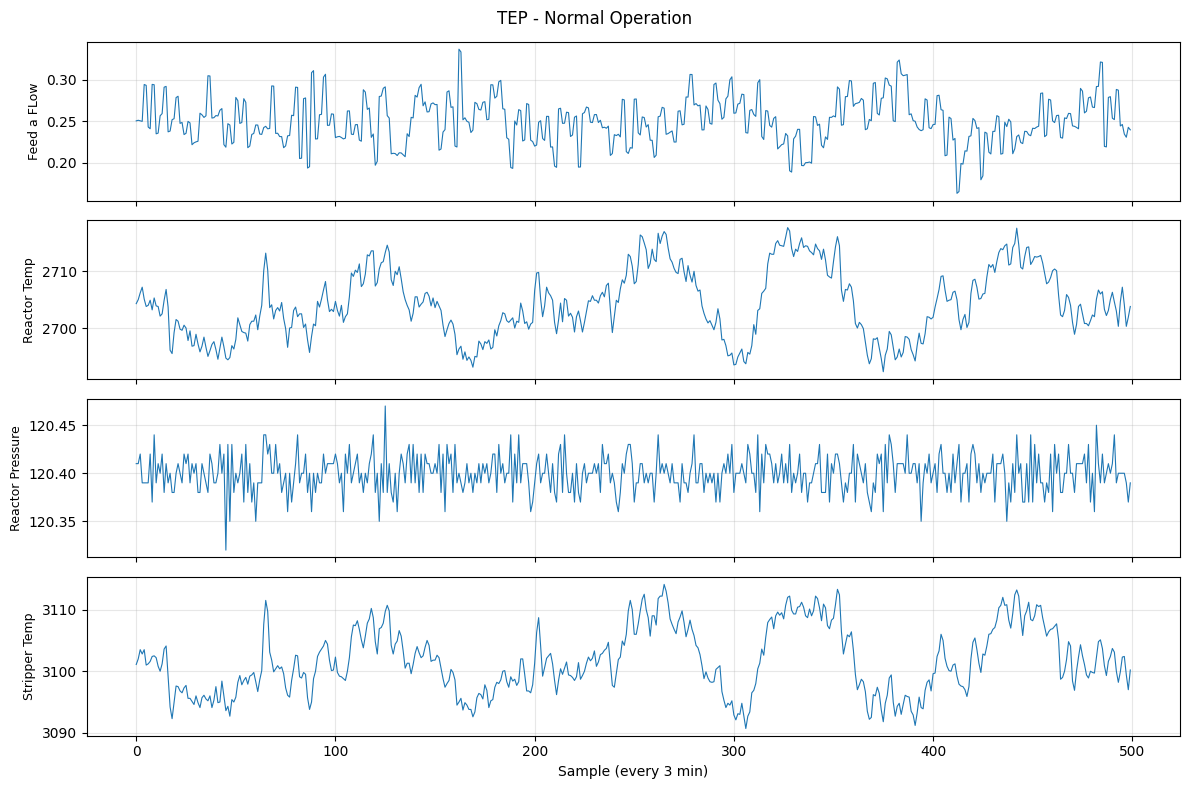

In [ ]:
import matplotlib.pyplot as plt

run_1 = df_normal[df_normal['simulationRun'] == 1].reset_index(drop=True)

# Plot 4 key sensors over time
sensors = ['xmeas_1', 'xmeas_7', 'xmeas_9', 'xmeas_16']
labels = ['Feed a FLow', 'Reactor Temp', 'Reactor Pressure', 'Stripper Temp']

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, col, label in zip(axes, sensors, labels):
    ax.plot(run_1[col], linewidth=0.8)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample (every 3 min)')
plt.suptitle('TEP - Normal Operation', fontsize=12)
plt.tight_layout()
plt.show

In [ ]:
import pandas as pd
import numpy as np
import pyreadr

# Load both datasets
result_normal = pyreadr.read_r('TEP_FaultFree_Training.RData')
result_fault = pyreadr.read_r('/TEP_Faulty_Training.RData')

df_normal = result_normal['fault_free_training']
df_fault = result_fault['faulty_training']

# Select only the 52 sensor columns (drop metadata columns)
sensor_cols = [col for col in df_normal.columns
               if col.startswith('xmeas') or col.startswith('xmv')]

print(f"Number of sensor columns: {len(sensor_cols)}")

Number of sensor columns: 52


In [ ]:
# Simulation run of normal data for training
X_train = df_normal[df_normal['simulationRun'].isin([1, 2, 3, 4, 5])][sensor_cols].values

# For testing: mix normal + fault 1 samples
normal_test = df_normal[df_normal['simulationRun'] == 2][sensor_cols].copy()
normal_test['label'] = 0 # 0 = normal

fault_test = df_fault[
    (df_fault['faultNumber'] == 1) &
    (df_fault['simulationRun'] == 1)
][sensor_cols].copy()
fault_test['label'] = 1 # 1 = anomaly

test_data = pd.concat([normal_test, fault_test]).reset_index(drop=True)
X_test = test_data[sensor_cols].values
y_test = test_data['label'].values

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 2500
Testing samples: 1000


In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,       # number of trees in the forest
    contamination=0.5,     # we expect ~5% of data to be anomalies
    random_state=42
)

model.fit(X_train)
print("Model trained!")

Model trained!


              precision    recall  f1-score   support

      Normal       0.41      0.68      0.51       500
     Anomaly       0.11      0.04      0.06       500

    accuracy                           0.36      1000
   macro avg       0.26      0.36      0.29      1000
weighted avg       0.26      0.36      0.29      1000



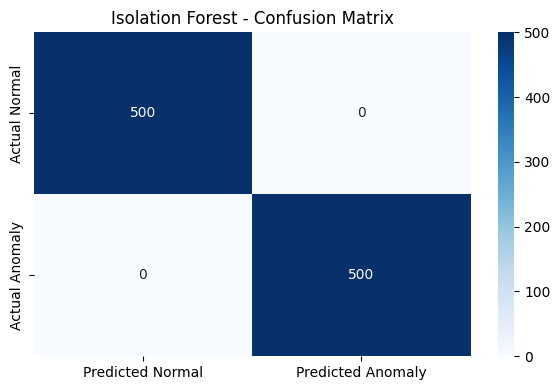

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict: -1 = anomaly, 1 = normal (sklearn convention)
y_pred_raw = model.predict(X_test)

# Convert to 0/1 to match our labels
y_pred = (y_pred_raw == 1).astype(int)

# Print performance report
print(classification_report(y_test, y_pred,
                            target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Isolation Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

## Isolation Forest

Unsupervised tree-based anomaly detection. Trains on normal data only.
Points that are easy to isolate (short path length) are flagged as anomalies.

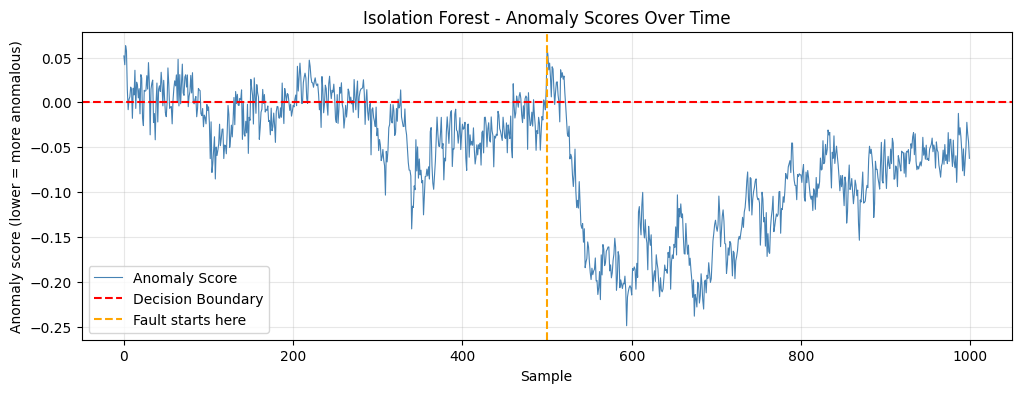

In [ ]:
# Anomaly score: more negative = more anomalous
scores = model.decision_function(X_test)

plt.figure(figsize=(12,4))
plt.plot(scores, linewidth=0.8, color='steelblue', label='Anomaly Score')
plt.axhline(0, color='red', linestyle='--', label='Decision Boundary')
plt.axvline(len(normal_test), color='orange', linestyle='--', label='Fault starts here')
plt.xlabel('Sample')
plt.ylabel('Anomaly score (lower = more anomalous)')
plt.title('Isolation Forest - Anomaly Scores Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
scaler = StandardScaler()

# Fit ONLY on normal training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

print(f"Mean of training data after scaling: {X_train_scaled.mean():.4f}")
print(f"Std of training data after scaling: {X_train_scaled.std():.4f}")
print(f"New training size: {X_train.shape[0]} samples")

Mean of training data after scaling: 0.0000
Std of training data after scaling: 1.0000
New training size: 2500 samples


## Autoencoder Neural Network

Architecture: 52 -> 32 -> 16 -> 8 -> 16 -> 32 -> 52

Trained to reconstruct normal sensor patterns. High reconstruction error indicates an unfamiliar (faulty) operating condition.





In [ ]:
input_dim = X_train_scaled.shape[1]     # 52 sensors

# Build the model
autoencoder = keras.Sequential([
    # Encoder
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),    # bottleneck

    # Decoder
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(input_dim, activation='linear')  # reconstruct original
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 52)             │         1,716 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,764 (18.61 KB)

 Trainable params: 4,764 (18.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.9917 - val_loss: 1.0174
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9424 - val_loss: 0.9033
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8710 - val_loss: 0.8318
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8163 - val_loss: 0.7734
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7540 - val_loss: 0.7319
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7177 - val_loss: 0.7095
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6957 - val_loss: 0.6955
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6803 - val_loss: 0.6835
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6686 - val_loss: 0.6689
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6570 - val_loss: 0.6604
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6463 - val_loss: 0.6472
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

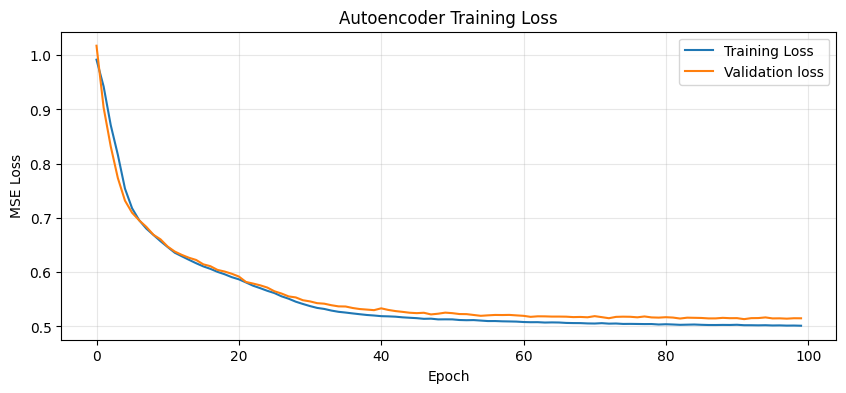

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)



history = autoencoder.fit(
    X_train_scaled, X_train_scaled,      # input = output(reconstruction)
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Model Comparison & Conclusions

Comparing Isolation Forest vs Autoencoder on Fault 1 detection

In [ ]:
# Reconstruct test data
X_test_reconstructed = autoencoder.predict(X_test_scaled)

# Reconstruct error per sample (mean squared error)
reconstruction_error = np.mean(
    np.square(X_test_scaled - X_test_reconstructed),
    axis=1
)

print(f"Mean error - Normal: {reconstruction_error[:500].mean():.4f}")
print(f"Mean error - Fault 1: {reconstruction_error[500:].mean():.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean error - Normal: 0.5183
Mean error - Fault 1: 8.4681


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Anomaly threshold: 0.7202
              precision    recall  f1-score   support

      Normal       0.95      0.94      0.95       500
     Anomaly       0.94      0.95      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



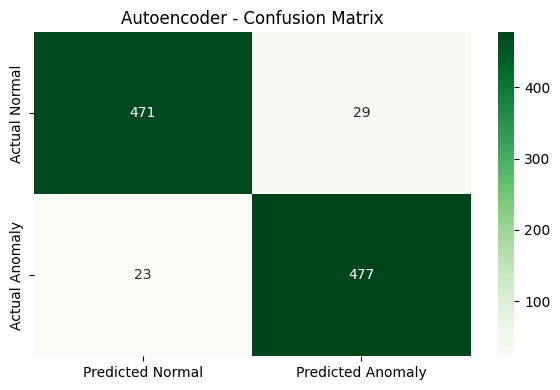

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set threshold at 95th percentile of normal training errors
train_reconstructed = autoencoder.predict(X_train_scaled)
train_errors = np.mean(np.square(X_train_scaled - train_reconstructed), axis=1)
threshold = np.percentile(train_errors, 95)

print(f"Anomaly threshold: {threshold:.4f}")

# Classify
y_pred = (reconstruction_error > threshold).astype(int)

print(classification_report(y_test, y_pred,
       target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Autoencoder - Confusion Matrix')
plt.tight_layout()
plt.show()

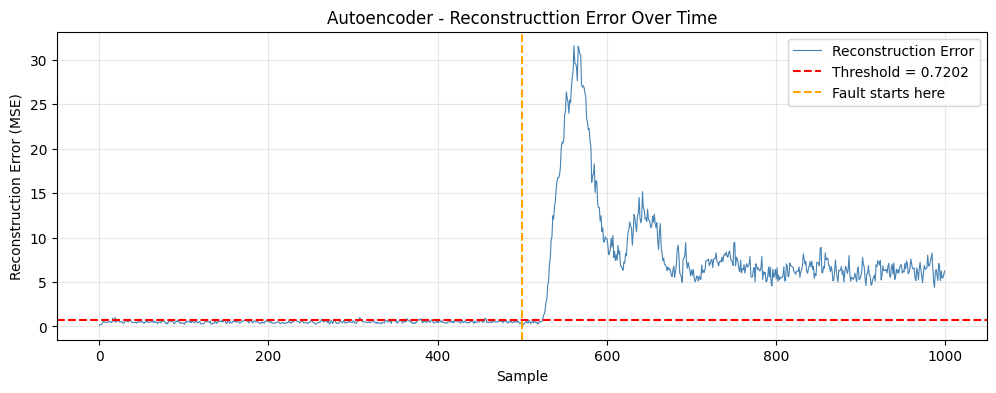

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(reconstruction_error, linewidth=0.8,
         color='steelblue', label='Reconstruction Error')
plt.axhline(threshold, color='red', linestyle='--',
            label=f'Threshold = {threshold:.4f}')
plt.axvline(500, color='orange', linestyle='--',
            label='Fault starts here')
plt.xlabel('Sample')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('Autoencoder - Reconstructtion Error Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()